# Titanic - Clasificación supervisada binaria
---
Autor: Pablo García Santos
 
## Pregunta del problema
> A partir de la información disponible sobre cada pasajero, ¿podemos predecir si sobrevivió (`1`) o no sobrevivió (`0`)?

## Contenidos
1. qué es una **clasificación supervisada binaria**;
2. cómo se inspecciona un dataset real;
3. cómo se hace un **análisis exploratorio de datos (EDA)**;
4. cómo se preparan variables numéricas y categóricas;
5. cómo se separan los datos en entrenamiento y prueba;
6. cómo se entrena un modelo de clasificación;
7. cómo se evalúa con métricas como **accuracy, sensitivity, specificity y balanced accuracy**;
8. cómo interpretar una **matriz de confusión**;
9. cómo revisar qué variables han sido más importantes para el modelo.

## Estructura del notebook
1. Fundamento teórico  
2. Importación de librerías  
3. Carga del dataset  
4. Exploración inicial  
5. Calidad de datos  
6. Análisis exploratorio (EDA)  
7. Preparación de datos  
8. Entrenamiento del modelo  
9. Evaluación del modelo  
10. Interpretación y conclusiones finales


## 1. Fundamento teórico

### 1.1. ¿Qué es aprendizaje supervisado?
En aprendizaje supervisado trabajamos con ejemplos donde ya conocemos la respuesta correcta.  
Cada fila del dataset contiene:

- unas variables de entrada o características (features), por ejemplo: sexo, edad o clase del billete;
- una variable objetivo (target), en este caso: si la persona sobrevivió o no.

El modelo intenta aprender una relación entre ambas cosas.

### 1.2. ¿Qué es clasificación binaria?
La clasificación binaria es un problema en el que la variable objetivo solo puede tomar dos valores:

- `0` → no sobrevivió  
- `1` → sobrevivió

### 1.3. ¿Por qué no basta con entrenar el modelo?
Porque un modelo puede memorizar muy bien los datos que ya ha visto.  
Por eso se divide el dataset en:

- **conjunto de entrenamiento**: sirve para aprender;
- **conjunto de prueba**: sirve para comprobar si el modelo generaliza bien.

### 1.4. Métricas principales

- **Accuracy**: porcentaje total de aciertos.
- **Sensitivity / Recall**: capacidad para detectar correctamente la clase positiva.
- **Specificity**: capacidad para detectar correctamente la clase negativa.
- **Balanced Accuracy**: promedio entre sensitivity y specificity.
- **Matriz de confusión**: resumen visual de aciertos y errores.

### 1.5. Idea general del pipeline

1. cargar los datos;
2. entender las variables;
3. revisar nulos y calidad;
4. explorar patrones;
5. preparar variables;
6. dividir en entrenamiento y prueba;
7. entrenar el modelo;
8. evaluar resultados;
9. interpretar el comportamiento del modelo.


In [ ]:
# ---------------------------------------------------------------------
# 1. Instalación de dependencias necesarias para ejecutar este notebook
# ---------------------------------------------------------------------

%pip install numpy pandas matplotlib seaborn scikit-learn jinja2 ipython


In [119]:
# ---------------------------------------------------------------------
# Importación de librerías y configuración del entorno
# ---------------------------------------------------------------------

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

## 2.1. Nota importante sobre el dataset

Vamos a usar el dataset Titanic incluido  en `seaborn`.  



In [120]:
# ---------------------------------------------------------------------
# 3. Carga del dataset
# ---------------------------------------------------------------------

datos = sns.load_dataset("titanic").copy()

print("Dimensiones del dataset:", datos.shape)
display(datos.head())


Dimensiones del dataset: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 3.1. Primeras observaciones

Cada fila representa a un pasajero del Titanic.  
La variable que queremos predecir es:

- `survived`:
  - `0` → no sobrevivió
  - `1` → sobrevivió

Antes de modelar, es imprescindible entender qué significan las demás columnas.


In [121]:
# ---------------------------------------------------------------------
# 4. Diccionario básico de variables
# ---------------------------------------------------------------------

diccionario_columnas = pd.DataFrame({
    "columna": [
        "survived", 
        "pclass", 
        "sex", 
        "age", 
        "sibsp", 
        "parch", 
        "fare",
        "embarked", 
        "class", 
        "who", 
        "adult_male", 
        "deck", 
        "embark_town",
        "alive", 
        "alone"
    ],
    "descripcion": [
        "Variable objetivo: 1 si sobrevivió, 0 si no sobrevivió",
        "Clase del billete (1 = primera, 2 = segunda, 3 = tercera)",
        "Sexo del pasajero",
        "Edad del pasajero",
        "Número de hermanos o cónyuges a bordo",
        "Número de padres o hijos a bordo",
        "Precio del billete",
        "Puerto de embarque",
        "Versión categórica de la clase del billete",
        "Tipo general de persona (man, woman, child)",
        "Indicador de hombre adulto",
        "Cubierta del barco",
        "Nombre de la ciudad/puerto de embarque",
        "Variable textual equivalente al target: alive / dead",
        "Indicador de si viajaba solo o acompañado"
    ]
})

display(diccionario_columnas)


,columna,descripcion
0,survived,"Variable objetivo: 1 si sobrevivió, 0 si no so..."
1,pclass,"Clase del billete (1 = primera, 2 = segunda, 3..."
2,sex,Sexo del pasajero
3,age,Edad del pasajero
4,sibsp,Número de hermanos o cónyuges a bordo
5,parch,Número de padres o hijos a bordo
6,fare,Precio del billete
7,embarked,Puerto de embarque
8,class,Versión categórica de la clase del billete
9,who,"Tipo general de persona (man, woman, child)"


In [122]:
# ---------------------------------------------------------------------
# 5. Exploración inicial
# ---------------------------------------------------------------------

print("Información general del dataset:")
print(datos.info())

print("\nResumen estadístico de variables numéricas:")
display(datos.describe().T)

print("\nResumen estadístico ampliado (incluye categóricas):")
display(datos.describe(include="all").T)


Información general del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
None

Resumen estadístico de variables numéricas:


,count,mean,std,min,25%,50%,75%,max
survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
sibsp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292



Resumen estadístico ampliado (incluye categóricas):


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,891,3,Third,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,891,3,man,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5.1. Qué debemos mirar ahora

En esta fase inicial nos interesa responder a estas preguntas:

- ¿cuántas filas y columnas tiene el dataset?
- ¿qué tipos de variables hay?
- ¿hay valores nulos?
- ¿hay duplicados?
- ¿la variable objetivo está equilibrada o desbalanceada?


In [123]:
# ---------------------------------------------------------------------
# 6. Calidad de datos
# ---------------------------------------------------------------------

tabla_nulos = datos.isnull().sum().sort_values(ascending=False).to_frame("nulos")
tabla_nulos["porcentaje_nulos"] = (tabla_nulos["nulos"] / len(datos) * 100).round(2)

print("Número de duplicados exactos:", datos.duplicated().sum())
display(tabla_nulos)


Número de duplicados exactos: 107


,nulos,porcentaje_nulos
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22
sex,0,0.00
pclass,0,0.00
survived,0,0.00
fare,0,0.00
parch,0,0.00
sibsp,0,0.00


### Interpretación de la calidad de datos

Al revisar los nulos, se observa lo siguiente:

- `deck` tiene muchos valores faltantes;
- `age` también presenta nulos;
- `embarked` tiene pocos nulos;
- la clase objetivo no está perfectamente equilibrada.

Esto es importante porque:

- los nulos obligan a aplicar estrategias de imputación;
- el desbalanceo hace recomendable mirar métricas adicionales a la accuracy.


## 7. Funciones auxiliares para el análisis exploratorio (EDA)

Vamos a definir funciones reutilizables para que el análisis sea homogéneo, claro y fácil de estudiar.


In [124]:
def graficar_variable_categorica(datos_entrada, nombre_columna, variable_objetivo="survived", top_n=None):
    """
    Muestra, para una variable categórica:
    1. el porcentaje de clase 0 y clase 1 dentro de cada categoría;
    2. el porcentaje de presencia de cada categoría en el dataset.

    Este tipo de gráfico es muy útil para responder dos preguntas:
    - ¿qué categorías aparecen más?
    - dentro de cada categoría, ¿cómo se reparte la supervivencia?
    """

    tabla = datos_entrada[[nombre_columna, variable_objetivo]].copy()
    tabla[nombre_columna] = tabla[nombre_columna].astype("object").fillna("Desconocido")

    if top_n is not None:
        categorias_top = tabla[nombre_columna].value_counts().head(top_n).index
        tabla[nombre_columna] = np.where(
            tabla[nombre_columna].isin(categorias_top),
            tabla[nombre_columna],
            "Otras"
        )

    porcentaje_presencia = (
        tabla[nombre_columna]
        .value_counts(normalize=True)
        .sort_values(ascending=False)
        .mul(100)
    )

    porcentaje_por_clase = (
        pd.crosstab(tabla[nombre_columna], tabla[variable_objetivo], normalize="index")
        .mul(100)
        .reindex(porcentaje_presencia.index)
    )

    plt.figure(figsize=(12, 6))

    plt.bar(
        porcentaje_por_clase.index,
        porcentaje_por_clase.get(0, pd.Series(0, index=porcentaje_por_clase.index)),
        label="% clase 0"
    )

    plt.bar(
        porcentaje_por_clase.index,
        porcentaje_por_clase.get(1, pd.Series(0, index=porcentaje_por_clase.index)),
        bottom=porcentaje_por_clase.get(0, pd.Series(0, index=porcentaje_por_clase.index)),
        label="% clase 1"
    )

    plt.plot(
        porcentaje_presencia.index,
        porcentaje_presencia.values,
        linestyle="-.",
        marker="o",
        color="red",
        label="% presencia"
    )

    plt.title(f"% de clase 0 y 1 en cada categoría de la variable {nombre_columna}")
    plt.xlabel(f"Categorías de la variable {nombre_columna}")
    plt.ylabel("%")
    plt.xticks(rotation=90)
    plt.legend()
    plt.tight_layout()
    plt.show()


def graficar_variable_numerica(datos_entrada, nombre_columna, variable_objetivo="survived"):
    """
    Muestra una variable numérica desde dos perspectivas:
    1. distribución general;
    2. comparación entre clases de la variable objetivo.

    Esto ayuda a ver si la variable puede separar mejor o peor a los grupos.
    """

    figura, ejes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(data=datos_entrada, x=nombre_columna, kde=True, ax=ejes[0])
    ejes[0].set_title(f"Distribución de {nombre_columna}")

    sns.boxplot(data=datos_entrada, x=variable_objetivo, y=nombre_columna, ax=ejes[1])
    ejes[1].set_title(f"{nombre_columna} según la variable objetivo")

    plt.tight_layout()
    plt.show()


## 8. Análisis exploratorio de la variable objetivo

Antes de estudiar el resto de variables, conviene observar la respuesta que queremos predecir.


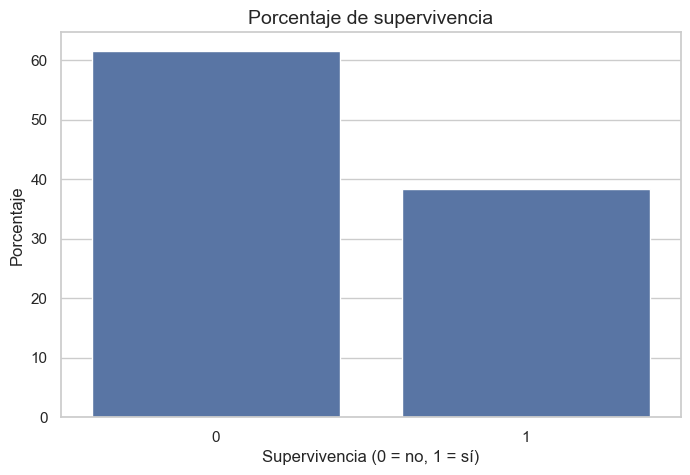

Porcentaje de no supervivencia: 61.62 %
Porcentaje de supervivencia: 38.38 %


In [125]:
plt.figure(figsize=(8, 5))
valores_supervivencia = datos["survived"].value_counts(normalize=True).sort_index() * 100
sns.barplot(x=valores_supervivencia.index, y=valores_supervivencia.values)
plt.title("Porcentaje de supervivencia")
plt.xlabel("Supervivencia (0 = no, 1 = sí)")
plt.ylabel("Porcentaje")
plt.show()

print("Porcentaje de no supervivencia:", round(valores_supervivencia.loc[0], 2), "%")
print("Porcentaje de supervivencia:", round(valores_supervivencia.loc[1], 2), "%")


## 9. Análisis exploratorio de variables categóricas

En esta sección estudiaremos cómo cambia la supervivencia según distintas variables categóricas.



--- Análisis de la variable categórica: sex ---


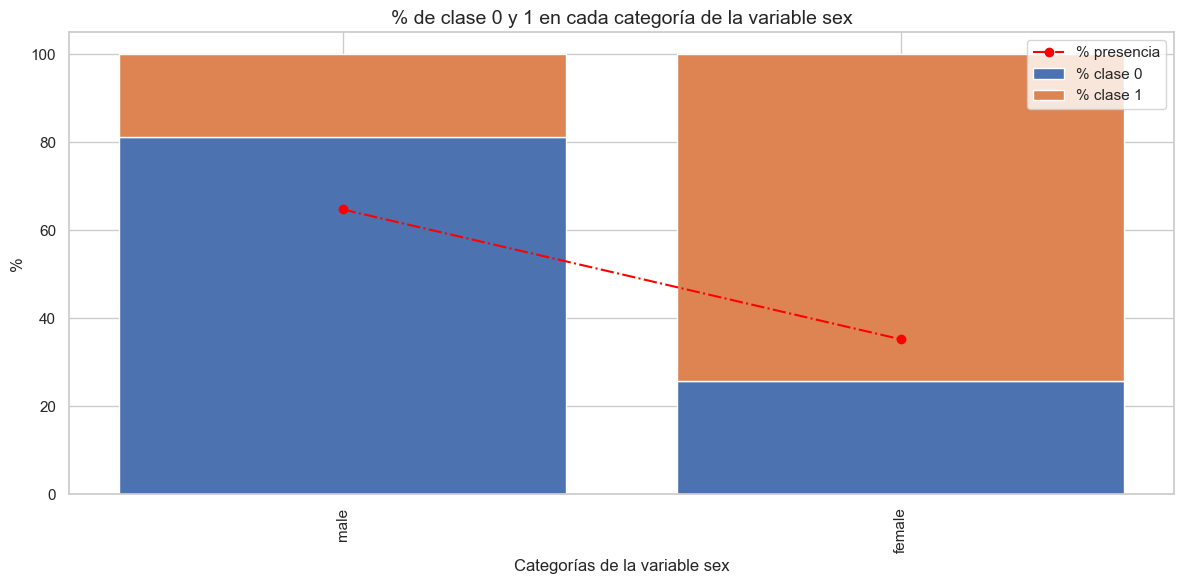


--- Análisis de la variable categórica: class ---


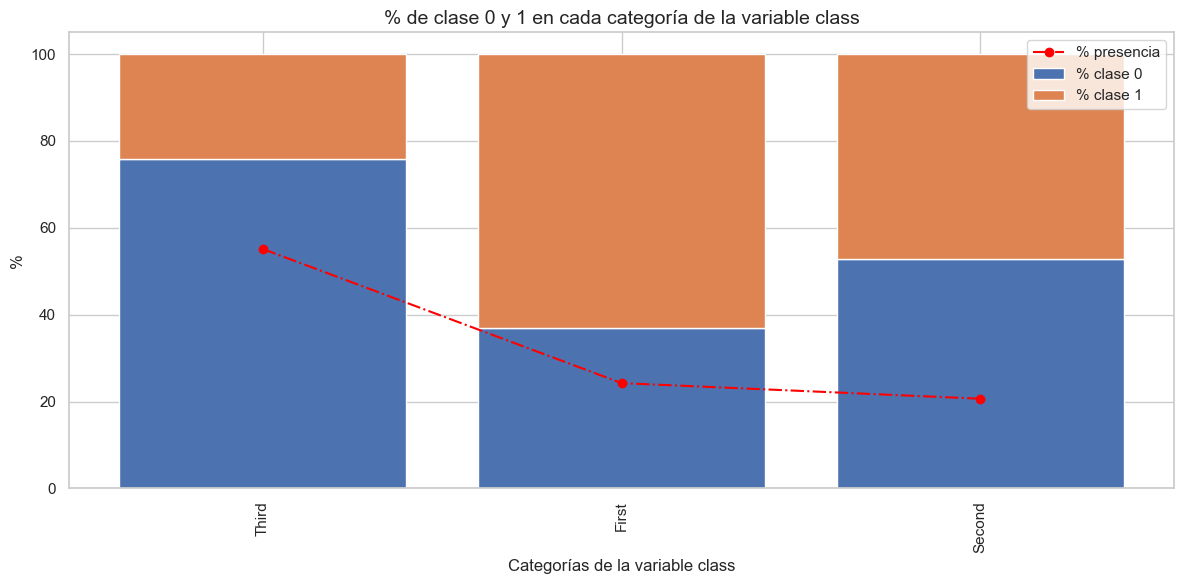


--- Análisis de la variable categórica: embarked ---


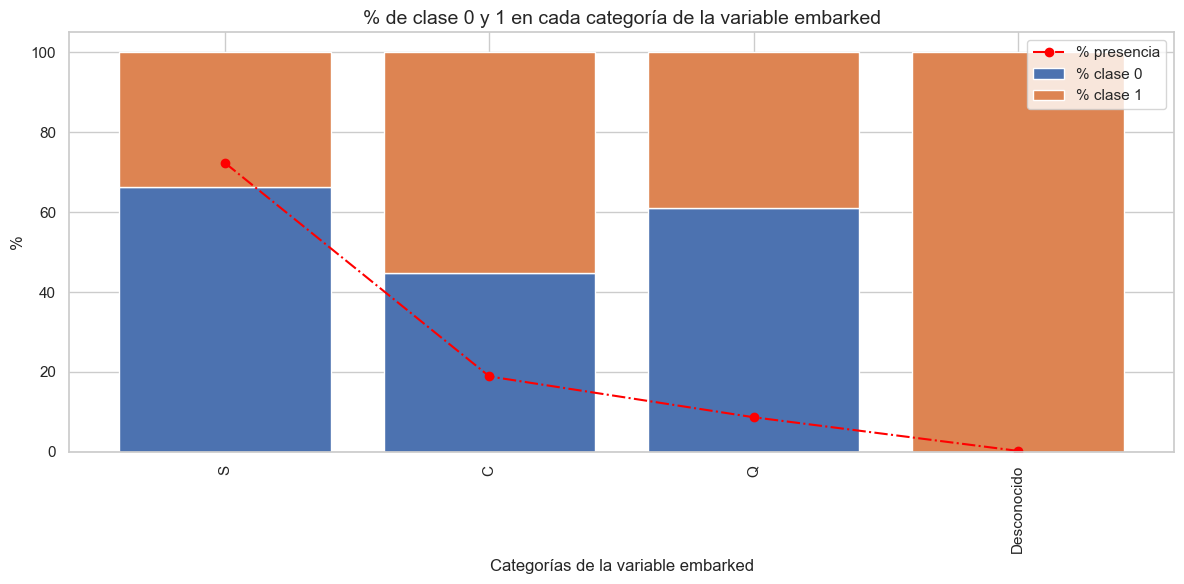


--- Análisis de la variable categórica: who ---


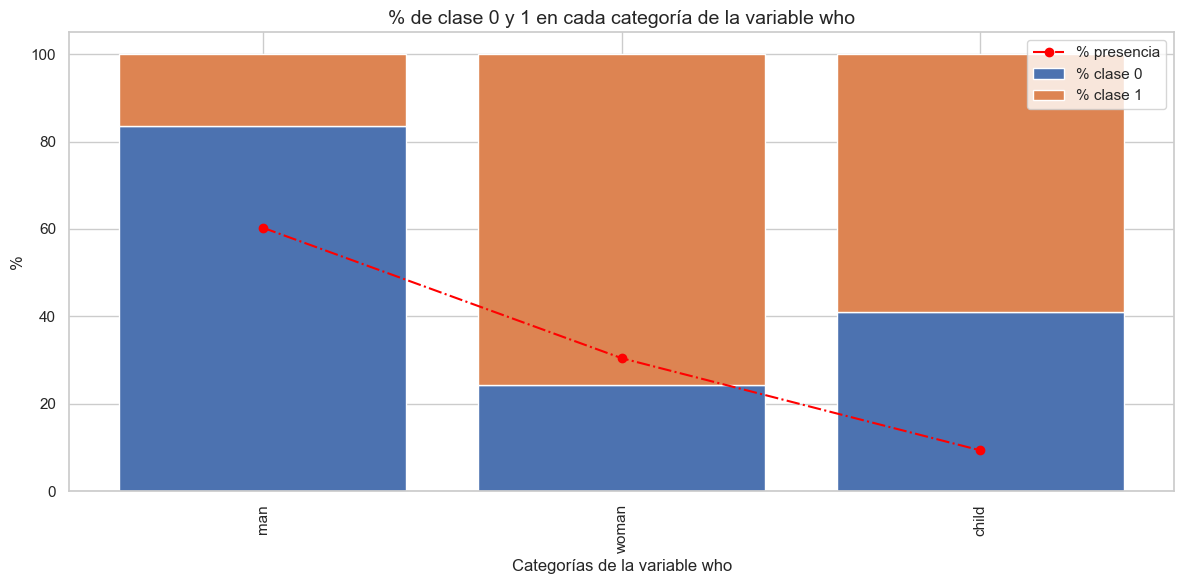


--- Análisis de la variable categórica: adult_male ---


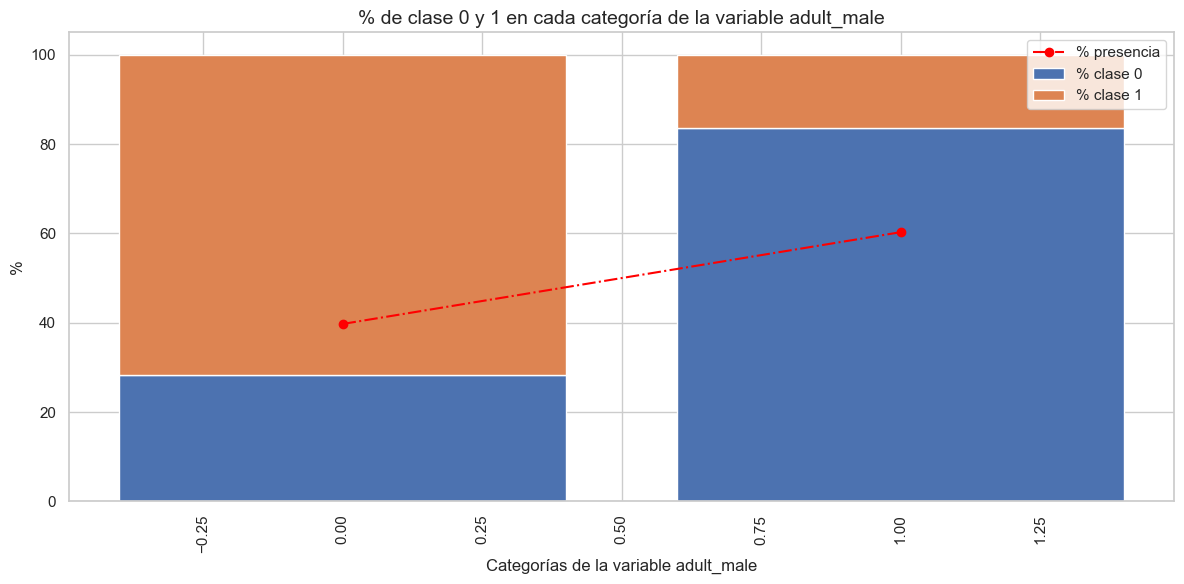


--- Análisis de la variable categórica: deck ---


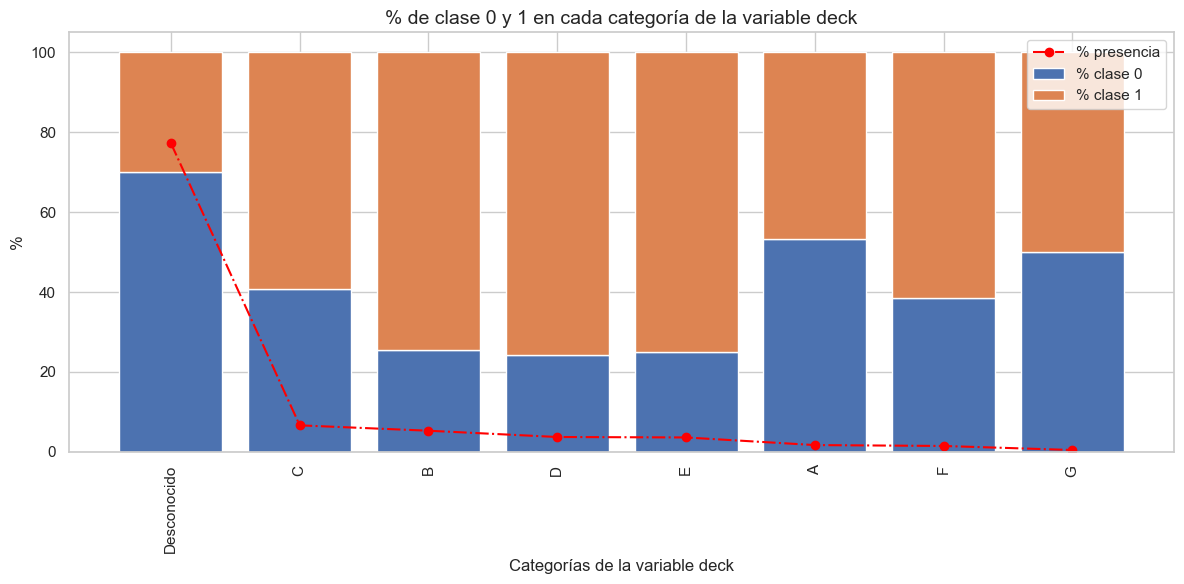


--- Análisis de la variable categórica: embark_town ---


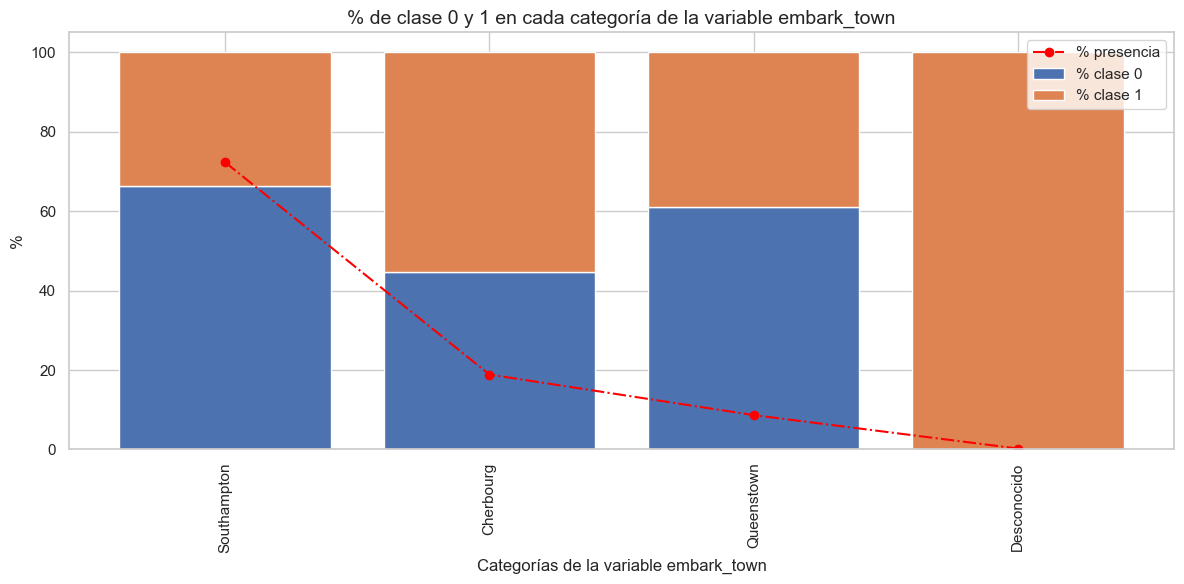


--- Análisis de la variable categórica: alone ---


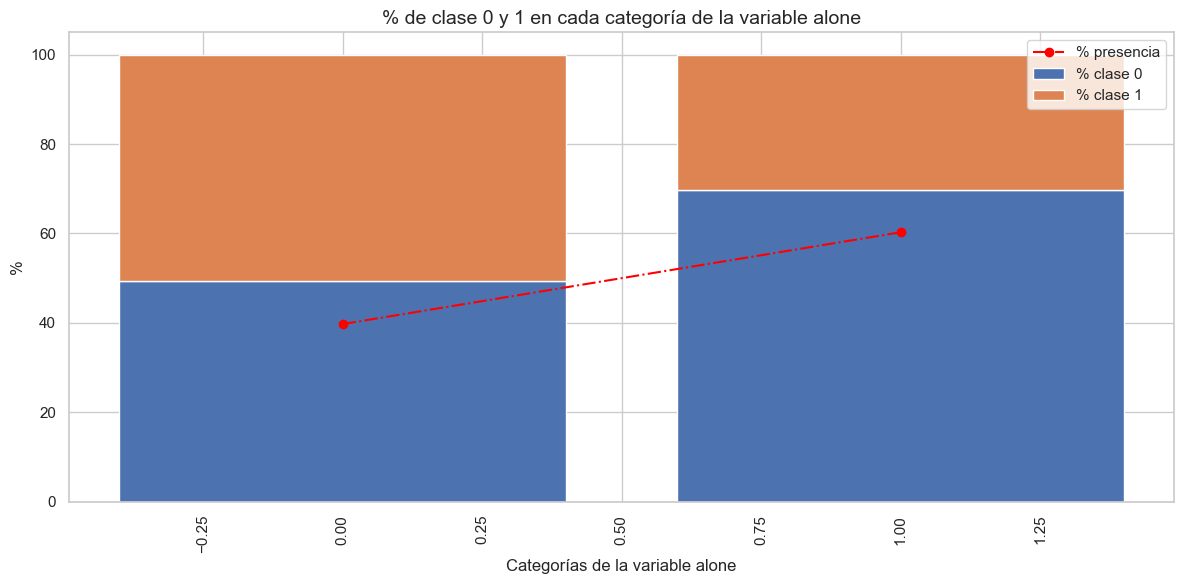

In [126]:
columnas_categoricas_eda = [
    "sex",
    "class",
    "embarked",
    "who",
    "adult_male",
    "deck",
    "embark_town",
    "alone"
]

for columna in columnas_categoricas_eda:
    print(f"\n--- Análisis de la variable categórica: {columna} ---")
    graficar_variable_categorica(datos, columna)


### Ideas clave que suelen aparecer en estas variables

A partir de estos gráficos, suelen observarse patrones muy relevantes:

- **`sex`**: la supervivencia femenina es claramente superior a la masculina.
- **`class` / `pclass`**: los pasajeros de clases más altas suelen sobrevivir más.
- **`who`**: la categoría `woman` suele mostrar una supervivencia alta.
- **`adult_male`**: suele asociarse con menor supervivencia.
- **`embarked` / `embark_town`**: pueden aparecer diferencias moderadas según el puerto.
- **`alone`**: viajar solo o acompañado puede influir, aunque normalmente con menos fuerza que sexo o clase.
- **`deck`**: puede aportar señal, pero tiene muchos nulos, por lo que hay que tratarla con cuidado.


## 10. Análisis exploratorio de variables numéricas
Ahora estudiaremos las variables numéricas más importantes.



--- Análisis de la variable numérica: age ---


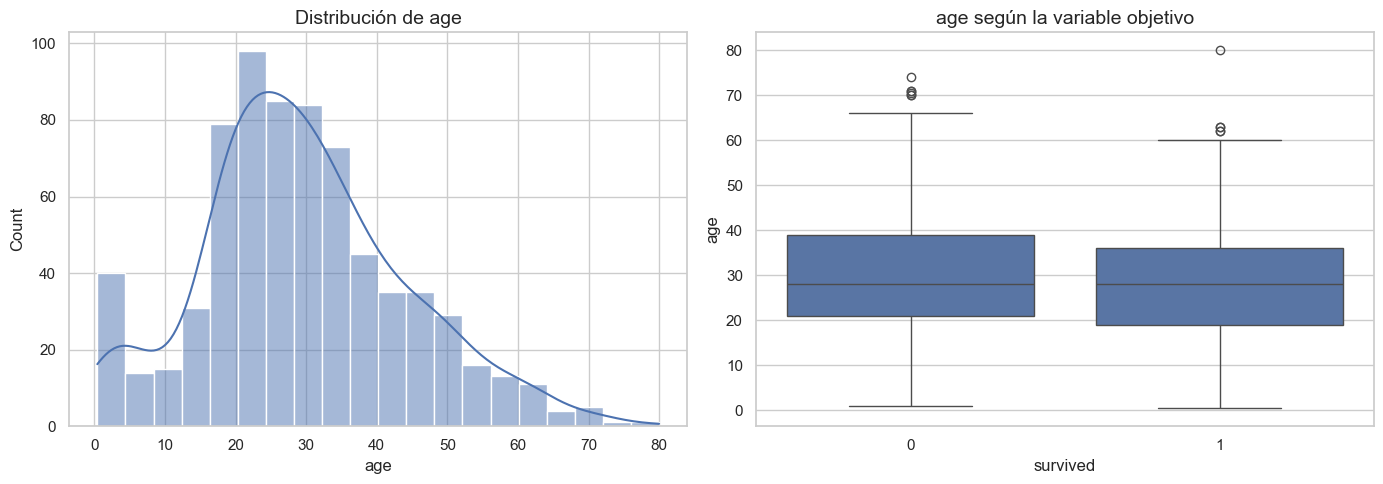


--- Análisis de la variable numérica: fare ---


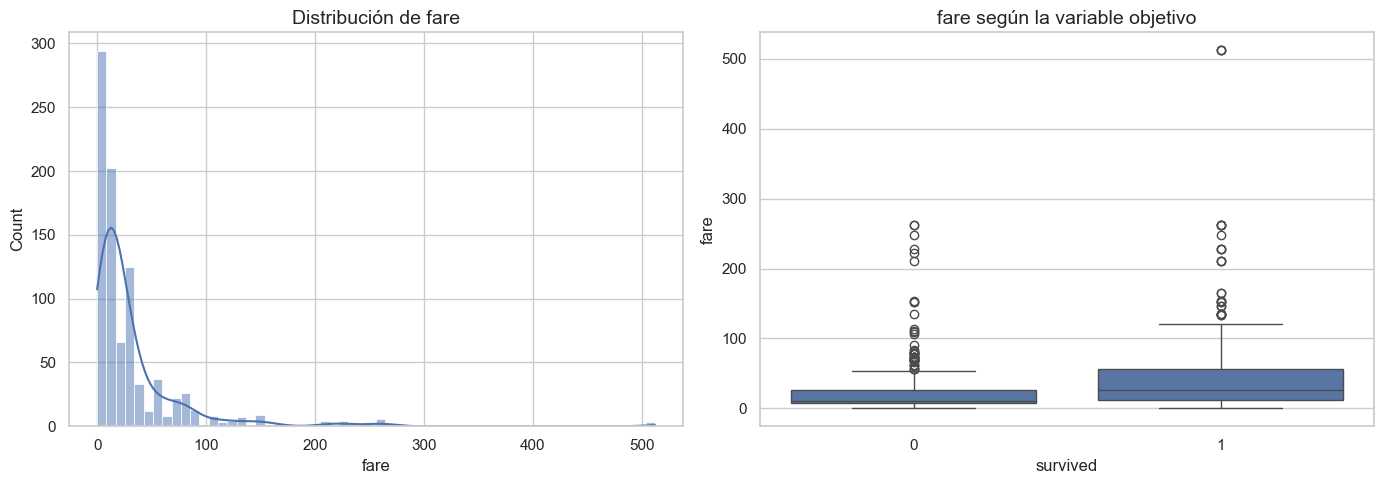


--- Análisis de la variable numérica: sibsp ---


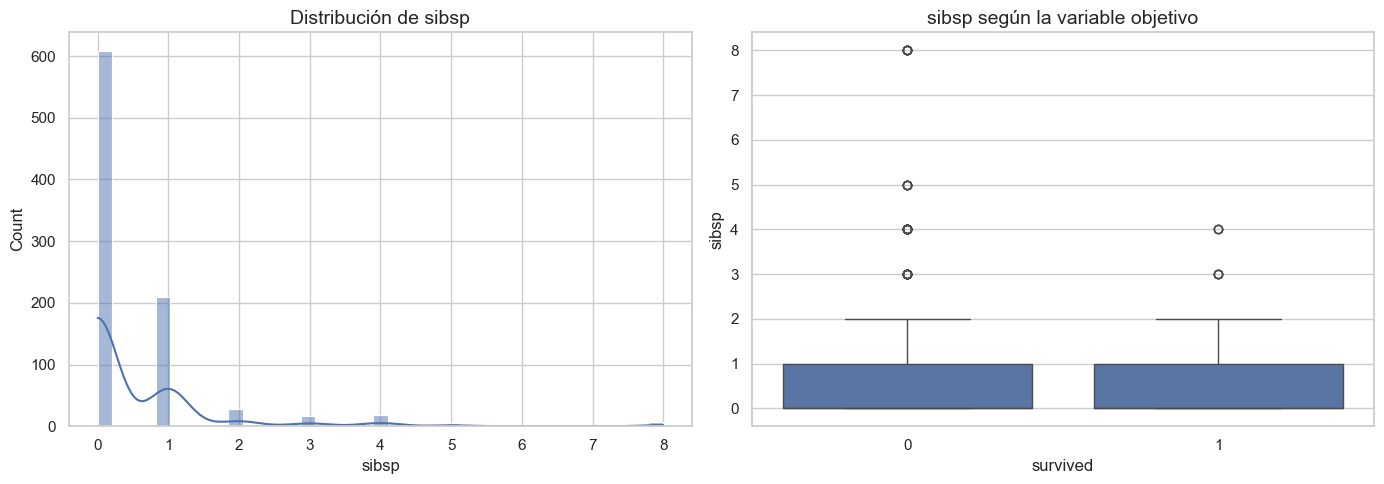


--- Análisis de la variable numérica: parch ---


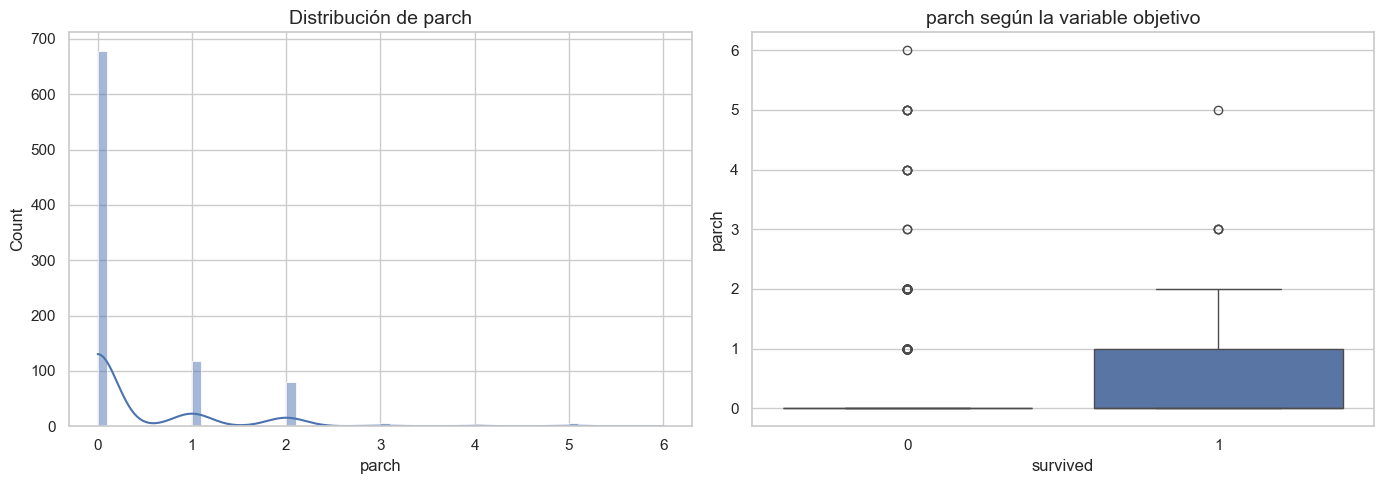

In [127]:
columnas_numericas_eda = ["age", "fare", "sibsp", "parch"]

for columna in columnas_numericas_eda:
    print(f"\n--- Análisis de la variable numérica: {columna} ---")
    graficar_variable_numerica(datos, columna)


### Posibles lecturas de las variables numéricas

- **`age`**: puede mostrar diferencias entre menores y adultos.
- **`fare`**: suele estar asociada con la clase del billete; tarifas más altas suelen relacionarse con mayor supervivencia.
- **`sibsp`** y **`parch`**: ayudan a captar el tamaño del entorno familiar a bordo.


## 11. Correlación entre variables numéricas

La correlación lineal no resuelve por sí sola el problema, pero ayuda a detectar relaciones entre variables.


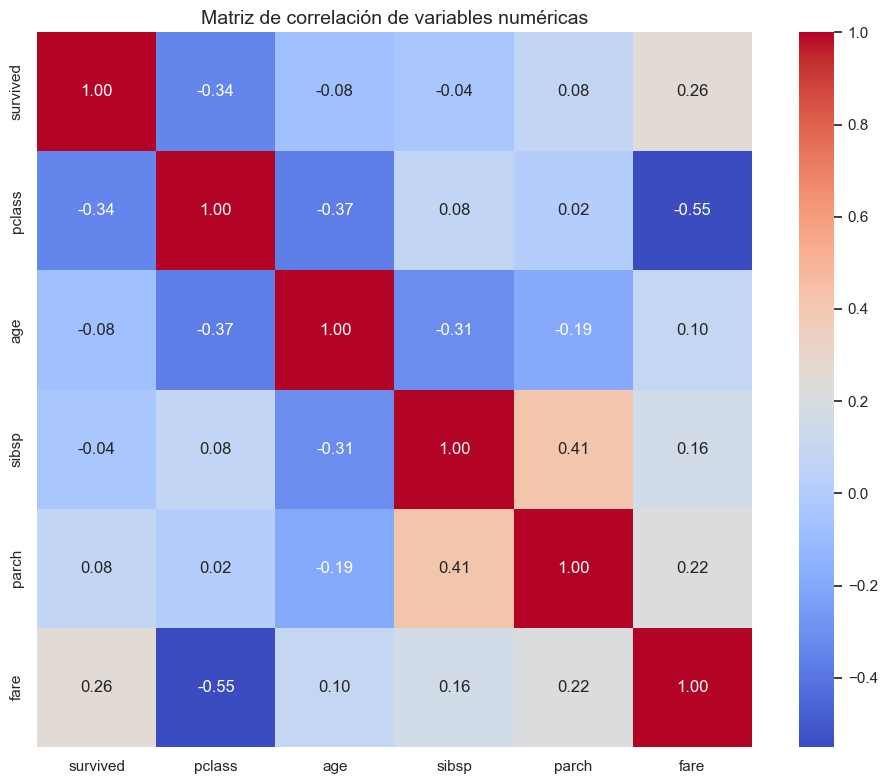

In [128]:
datos_numericos = datos.select_dtypes(include=[np.number]).copy()

plt.figure(figsize=(10, 8))
sns.heatmap(datos_numericos.corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Matriz de correlación de variables numéricas")
plt.tight_layout()
plt.show()


### Comentario
Vemos relación entre:

- `fare` y `pclass` / `class`;
- `sibsp` y `parch` en ciertos perfiles de viaje;
- `survived` con variables como `fare`, `pclass` y especialmente con variables relacionadas con sexo y tipo de pasajero.


## 12. Selección de variables para el modelo

No todas las columnas deben usarse.

### Columnas que no conviene usar
- `survived`: es el objetivo.
- `alive`: contiene la misma información que `survived` expresada como texto.  
  Usarla sería una fuga de información (data leakage), porque le estaría diciendo al modelo la respuesta.

### Columnas que sí usaremos
Trabajaremos con una selección razonable de variables numéricas y categóricas.


In [129]:
# ---------------------------------------------------------------------
# 13. Construcción del dataset de modelado
# ---------------------------------------------------------------------

columnas_modelo = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked",
    "class",
    "who",
    "adult_male",
    "deck",
    "embark_town",
    "alone"
]

columna_objetivo = "survived"

datos_modelo = datos[columnas_modelo + [columna_objetivo]].copy()

print("Dimensiones del dataset de modelado:", datos_modelo.shape)
display(datos_modelo.head())


Dimensiones del dataset de modelado: (891, 14)


,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone,survived
0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,False,0
1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,False,1
2,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,True,1
3,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,False,1
4,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,True,0


In [130]:
# Separación entre variables predictoras y variable objetivo
caracteristicas = datos_modelo.drop(columns=[columna_objetivo]).copy()
objetivo = datos_modelo[columna_objetivo].copy()

columnas_categoricas = caracteristicas.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
columnas_numericas = caracteristicas.select_dtypes(include=[np.number]).columns.tolist()

# Normalización del tipo de las variables categóricas para evitar
# incompatibilidades entre pandas y scikit-learn en la imputación/codificación.
caracteristicas[columnas_categoricas] = caracteristicas[columnas_categoricas].astype("object")

# Relleno explícito de nulos en variables categóricas antes del pipeline.
# Así evitamos que SimpleImputer(strategy="most_frequent") falle con texto.
caracteristicas[columnas_categoricas] = caracteristicas[columnas_categoricas].fillna("Desconocido")

print("Columnas categóricas:", columnas_categoricas)
print("Columnas numéricas :", columnas_numericas)


Columnas categóricas: ['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alone']
Columnas numéricas : ['pclass', 'age', 'sibsp', 'parch', 'fare']


## 14. División en entrenamiento y prueba

Separaremos el dataset en:

- **75% entrenamiento**
- **25% prueba**

Se usará `stratify=objetivo` para que la proporción de supervivencia sea similar en ambos subconjuntos.


In [131]:
caracteristicas_entrenamiento, caracteristicas_prueba, objetivo_entrenamiento, objetivo_prueba = train_test_split(
    caracteristicas,
    objetivo,
    test_size=0.25,
    random_state=42,
    stratify=objetivo
)

print("caracteristicas_entrenamiento:", caracteristicas_entrenamiento.shape)
print("caracteristicas_prueba       :", caracteristicas_prueba.shape)
print("objetivo_entrenamiento      :", objetivo_entrenamiento.shape)
print("objetivo_prueba             :", objetivo_prueba.shape)


caracteristicas_entrenamiento: (668, 13)
caracteristicas_prueba       : (223, 13)
objetivo_entrenamiento      : (668,)
objetivo_prueba             : (223,)


## 15. Preprocesamiento

Como hay variables de distinto tipo, necesitamos tratarlas de forma diferente.

### Para variables numéricas
- imputación de nulos con la mediana

### Para variables categóricas
- imputación de nulos con la moda (valor más frecuente)
- codificación One-Hot Encoding

Evitamos incoherencias entre entrenamiento y prueba.


In [132]:
transformador_numerico = Pipeline(
    steps=[
        ("imputador", SimpleImputer(strategy="median"))
    ]
)

transformador_categorico = Pipeline(
    steps=[
        ("imputador", SimpleImputer(strategy="most_frequent")),
        ("one_hot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocesador = ColumnTransformer(
    transformers=[
        ("num", transformador_numerico, columnas_numericas),
        ("cat", transformador_categorico, columnas_categoricas)
    ]
)


## 16. Selección del modelo

Elegimos un Random Forest Classifier porque:

- funciona bien con relaciones no lineales;
- es robusto;
- suele dar buenos resultados en datasets tabulares;
- permite interpretar la importancia de las variables;
- resulta adecuado para una primera aproximación sólida.


In [133]:
modelo = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    class_weight="balanced"
)

tuberia_modelado = Pipeline(
    steps=[
        ("preprocesador", preprocesador),
        ("modelo", modelo)
    ]
)


## 17. Entrenamiento del modelo


In [134]:
tuberia_modelado.fit(caracteristicas_entrenamiento, objetivo_entrenamiento)

print("Modelo entrenado correctamente.")


Modelo entrenado correctamente.


## 18. Predicción sobre entrenamiento y prueba
También obtendremos probabilidades, ya que nos servirán para métricas como **ROC AUC**.


In [135]:
prediccion_entrenamiento = tuberia_modelado.predict(caracteristicas_entrenamiento)
prediccion_prueba = tuberia_modelado.predict(caracteristicas_prueba)

probabilidad_entrenamiento = tuberia_modelado.predict_proba(caracteristicas_entrenamiento)[:, 1]
probabilidad_prueba = tuberia_modelado.predict_proba(caracteristicas_prueba)[:, 1]

print("Predicciones entrenamiento:", prediccion_entrenamiento.shape)
print("Predicciones prueba       :", prediccion_prueba.shape)


Predicciones entrenamiento: (668,)
Predicciones prueba       : (223,)


## 19. Evaluación del modelo



In [136]:
# ---------------------------------------------------------------------
# Cálculo de métricas principales
# ---------------------------------------------------------------------

accuracy_entrenamiento = accuracy_score(objetivo_entrenamiento, prediccion_entrenamiento)
accuracy_prueba = accuracy_score(objetivo_prueba, prediccion_prueba)

precision_prueba = precision_score(objetivo_prueba, prediccion_prueba)
recall_prueba = recall_score(objetivo_prueba, prediccion_prueba)
f1_prueba = f1_score(objetivo_prueba, prediccion_prueba)
balanced_accuracy_prueba = balanced_accuracy_score(objetivo_prueba, prediccion_prueba)
roc_auc_prueba = roc_auc_score(objetivo_prueba, probabilidad_prueba)

matriz_confusion = confusion_matrix(objetivo_prueba, prediccion_prueba)
TN, FP, FN, TP = matriz_confusion.ravel()

specificity_prueba = TN / (TN + FP)

tabla_metricas = pd.DataFrame({
    "metrica": [
        "Accuracy train",
        "Accuracy test",
        "Precision test",
        "Recall / Sensitivity test",
        "Specificity test",
        "F1-score test",
        "Balanced Accuracy test",
        "ROC AUC test"
    ],
    "valor": [
        accuracy_entrenamiento,
        accuracy_prueba,
        precision_prueba,
        recall_prueba,
        specificity_prueba,
        f1_prueba,
        balanced_accuracy_prueba,
        roc_auc_prueba
    ]
})

display(tabla_metricas.style.format({"valor": "{:.4f}"}))

print("")
print(f"Accuracy train           : {accuracy_entrenamiento:.4f}")
print(f"Accuracy test            : {accuracy_prueba:.4f}")
print(f"Precision test           : {precision_prueba:.4f}")
print(f"Recall / Sensitivity test: {recall_prueba:.4f}")
print(f"Specificity test         : {specificity_prueba:.4f}")
print(f"F1-score test            : {f1_prueba:.4f}")
print(f"Balanced Accuracy test   : {balanced_accuracy_prueba:.4f}")
print(f"ROC AUC test             : {roc_auc_prueba:.4f}")
print("")


,metrica,valor
0,Accuracy train,0.9057
1,Accuracy test,0.7937
2,Precision test,0.7500
3,Recall / Sensitivity test,0.6977
4,Specificity test,0.8540
5,F1-score test,0.7229
6,Balanced Accuracy test,0.7758
7,ROC AUC test,0.8479



Accuracy train           : 0.9057
Accuracy test            : 0.7937
Precision test           : 0.7500
Recall / Sensitivity test: 0.6977
Specificity test         : 0.8540
F1-score test            : 0.7229
Balanced Accuracy test   : 0.7758
ROC AUC test             : 0.8479



### Cómo interpretar estas métricas

- **Accuracy**: de todas las predicciones, cuántas fueron correctas.
- **Precision**: cuando el modelo predice supervivencia, cuántas veces acierta.
- **Recall / Sensitivity**: de todos los que realmente sobrevivieron, cuántos detecta.
- **Specificity**: de todos los que realmente no sobrevivieron, cuántos detecta.
- **F1-score**: equilibrio entre *precision* y *recall*.
- **Balanced Accuracy**: promedio entre sensibilidad y especificidad.
- **ROC AUC**: calidad global del ranking de probabilidades del modelo.

> una sola métrica nunca cuenta toda la historia.


In [137]:
print("Classification report del conjunto de prueba:")
print(classification_report(objetivo_prueba, prediccion_prueba))


Classification report del conjunto de prueba:
              precision    recall  f1-score   support

           0       0.82      0.85      0.84       137
           1       0.75      0.70      0.72        86

    accuracy                           0.79       223
   macro avg       0.78      0.78      0.78       223
weighted avg       0.79      0.79      0.79       223



## 20. Matriz de confusión

La matriz de confusión resume los aciertos y errores del modelo:

- **TN**: verdaderos negativos  
- **FP**: falsos positivos  
- **FN**: falsos negativos  
- **TP**: verdaderos positivos


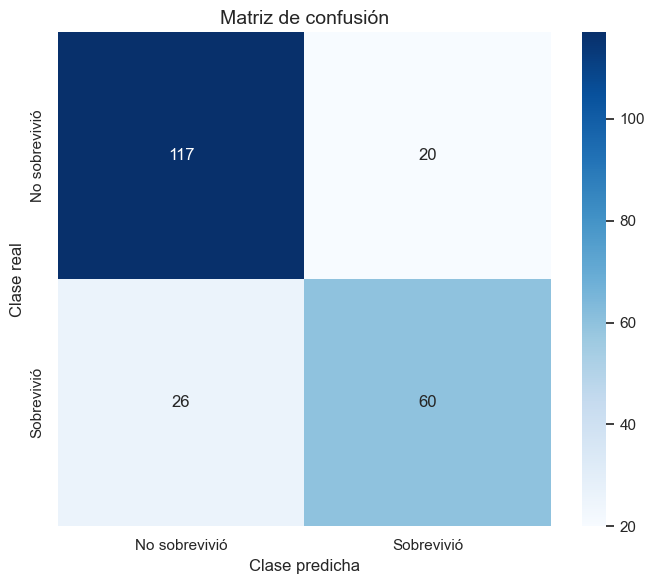

In [138]:
def graficar_matriz_confusion_binaria(y_real, y_predicha, nombres_clase=("No sobrevivió", "Sobrevivió")):
    """
    Representa la matriz de confusión de forma visual y añade los valores
    en cada celda para facilitar la interpretación.
    """

    matriz = confusion_matrix(y_real, y_predicha)

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        matriz,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=nombres_clase,
        yticklabels=nombres_clase
    )
    plt.title("Matriz de confusión")
    plt.xlabel("Clase predicha")
    plt.ylabel("Clase real")
    plt.tight_layout()
    plt.show()

graficar_matriz_confusion_binaria(objetivo_prueba, prediccion_prueba)


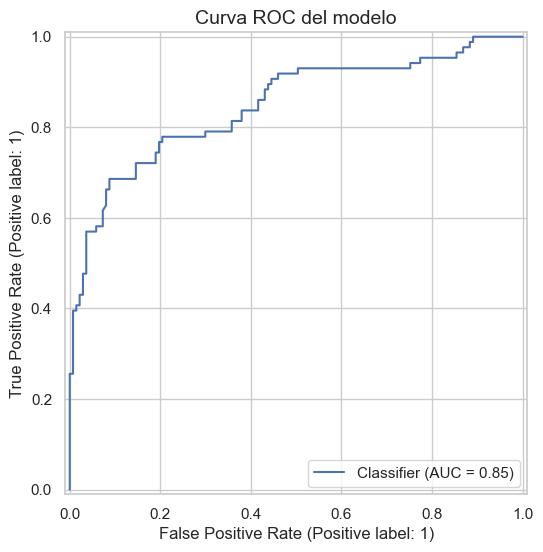

In [139]:
# Curva ROC
RocCurveDisplay.from_predictions(objetivo_prueba, probabilidad_prueba)
plt.title("Curva ROC del modelo")
plt.show()


## 21. Ejemplos correctamente clasificados y mal clasificados

Revisaremos ejemplos reales del conjunto de prueba:

- pasajeros bien clasificados;
- pasajeros mal clasificados.


In [140]:
resultados_prueba = caracteristicas_prueba.copy()
resultados_prueba["objetivo_real"] = objetivo_prueba.values
resultados_prueba["prediccion_modelo"] = prediccion_prueba
resultados_prueba["probabilidad_supervivencia"] = probabilidad_prueba
resultados_prueba["prediccion_correcta"] = (
    resultados_prueba["objetivo_real"] == resultados_prueba["prediccion_modelo"]
).astype(int)

ejemplos_correctos = resultados_prueba[resultados_prueba["prediccion_correcta"] == 1].head(10)
ejemplos_incorrectos = resultados_prueba[resultados_prueba["prediccion_correcta"] == 0].head(10)

print("Ejemplos correctamente clasificados:")
display(ejemplos_correctos)

print("Ejemplos mal clasificados:")
display(ejemplos_incorrectos)


Ejemplos correctamente clasificados:


,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone,objetivo_real,prediccion_modelo,probabilidad_supervivencia,prediccion_correcta
157,3,male,30.0,0,0,8.0500,S,Third,man,True,Desconocido,Southampton,True,0,0,0.200199,1
82,3,female,NaN,0,0,7.7875,Q,Third,woman,False,Desconocido,Queenstown,True,1,1,0.856389,1
683,3,male,14.0,5,2,46.9000,S,Third,child,False,Desconocido,Southampton,False,0,0,0.181398,1
84,2,female,17.0,0,0,10.5000,S,Second,woman,False,Desconocido,Southampton,True,1,1,0.929191,1
779,1,female,43.0,0,1,211.3375,S,First,woman,False,B,Southampton,False,1,1,0.985120,1
728,2,male,25.0,1,0,26.0000,S,Second,man,True,Desconocido,Southampton,False,0,0,0.167970,1
734,2,male,23.0,0,0,13.0000,S,Second,man,True,Desconocido,Southampton,True,0,0,0.047960,1
375,1,female,NaN,1,0,82.1708,C,First,woman,False,Desconocido,Cherbourg,False,1,1,0.988391,1
349,3,male,42.0,0,0,8.6625,S,Third,man,True,Desconocido,Southampton,True,0,0,0.198457,1
868,3,male,NaN,0,0,9.5000,S,Third,man,True,Desconocido,Southampton,True,0,0,0.291536,1


Ejemplos mal clasificados:


,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone,objetivo_real,prediccion_modelo,probabilidad_supervivencia,prediccion_correcta
501,3,female,21.0,0,0,7.7500,Q,Third,woman,False,Desconocido,Queenstown,True,0,1,0.880943,0
352,3,male,15.0,1,1,7.2292,C,Third,child,False,Desconocido,Cherbourg,False,0,1,0.711531,0
515,1,male,47.0,0,0,34.0208,S,First,man,True,D,Southampton,True,0,1,0.508127,0
347,3,female,NaN,1,0,16.1000,S,Third,woman,False,Desconocido,Southampton,False,1,0,0.252277,0
92,1,male,46.0,1,0,61.1750,S,First,man,True,E,Southampton,False,0,1,0.518734,0
826,3,male,NaN,0,0,56.4958,S,Third,man,True,Desconocido,Southampton,True,0,1,0.635806,0
271,3,male,25.0,0,0,0.0000,S,Third,man,True,Desconocido,Southampton,True,1,0,0.072976,0
142,3,female,24.0,1,0,15.8500,S,Third,woman,False,Desconocido,Southampton,False,1,0,0.294809,0
146,3,male,27.0,0,0,7.7958,S,Third,man,True,Desconocido,Southampton,True,1,0,0.230639,0
690,1,male,31.0,1,0,57.0000,S,First,man,True,B,Southampton,False,1,0,0.498368,0


## 22. Importancia de variables

Una ventaja del modelo elegido es que podemos estimar qué variables han pesado más en la decisión final.


In [141]:
nombres_variables_numericas = columnas_numericas

nombres_variables_categoricas = (
    tuberia_modelado.named_steps["preprocesador"]
    .named_transformers_["cat"]
    .named_steps["one_hot"]
    .get_feature_names_out(columnas_categoricas)
)

nombres_variables_finales = np.concatenate([
    nombres_variables_numericas,
    nombres_variables_categoricas
])

importancias = tuberia_modelado.named_steps["modelo"].feature_importances_

tabla_importancias = (
    pd.DataFrame({
        "variable": nombres_variables_finales,
        "importancia": importancias
    })
    .sort_values("importancia", ascending=False)
    .reset_index(drop=True)
)

display(tabla_importancias.head(20))


,variable,importancia
0,fare,0.149601
1,age,0.120691
2,adult_male_True,0.105989
3,who_man,0.098361
4,adult_male_False,0.076520
5,sex_female,0.064582
6,sex_male,0.060096
7,pclass,0.044032
8,who_woman,0.039570
9,deck_Desconocido,0.035462


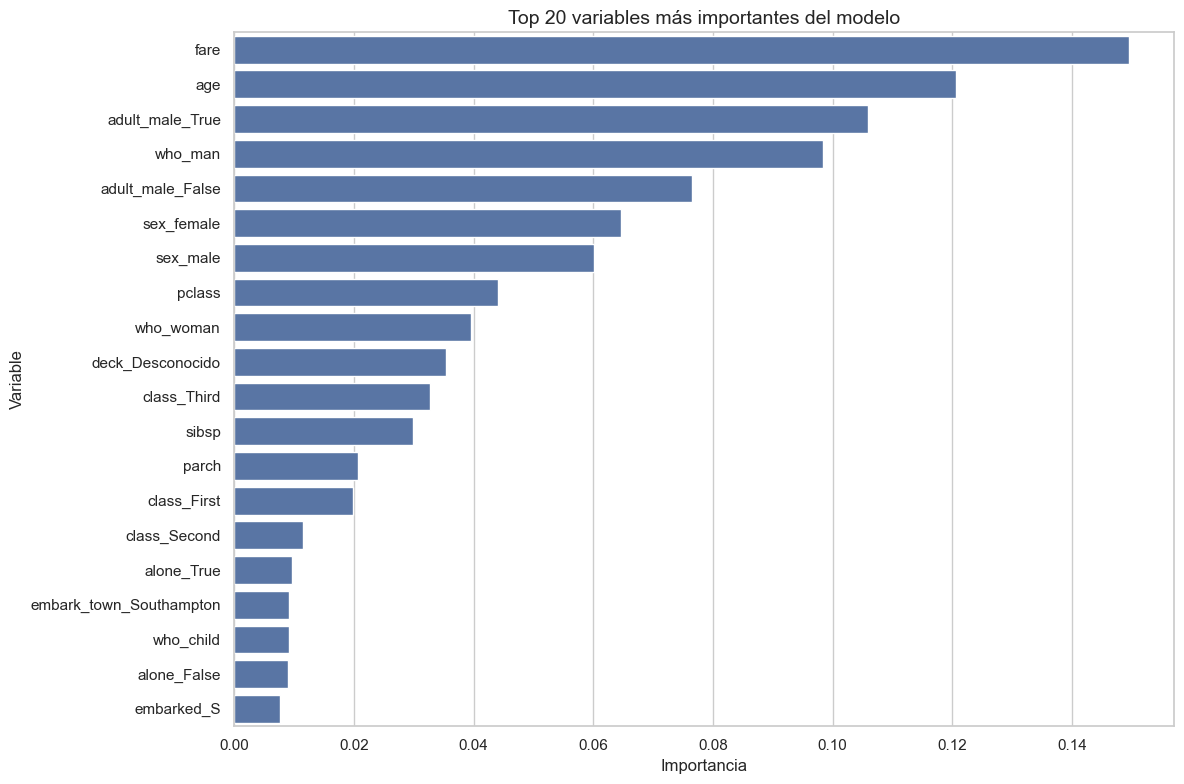

In [142]:
plt.figure(figsize=(12, 8))
sns.barplot(data=tabla_importancias.head(20), x="importancia", y="variable")
plt.title("Top 20 variables más importantes del modelo")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()


## 23. Resumen final

1. Cargar un dataset real;
2. Entender sus variables;
3. Revisar calidad;
4. Análisis exploratorio de variables categóricas y numéricas;
5. Preparar el dataset para modelado;
6. Construir un pipeline con preprocesamiento y modelo;
7. Entrenar un clasificador;
8. Evaluar sus resultados con varias métricas;
9. Interpretar errores y variables importantes.

### Ideas 
- Nunca modelar sin revisar antes los datos.
- Nunca usar una variable que filtre la respuesta, como `alive`.
- No usar solo con la *accuracy*.
- Mirar la matriz de confusión para entender los errores.

